[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniellopezcano/I-Escola-de-Inverno-do-IFUSP/blob/main/jax-examples/notebooks/L3B2_contrastive_embedding.ipynb)

# Notebook 02 — Embeddings Contrastivos
### Do espaco de pixels a representacoes sem rotulos
**I Escola de Inverno do IFUSP — Bloco L3B2**

> **Modo de uso:** demo guiada pelo instrutor; voces recebem o notebook depois.
> Ao final, teremos construido representacoes de digitos MNIST de duas
> formas — com rotulos (classificador) e sem rotulos (InfoNCE) — e visto
> por que o espaco de pixels cru nao funciona.

In [ ]:
# Instalacao de pacotes (so no Colab — localmente ja estao instalados)
import subprocess, sys
try:
    import google.colab  # noqa: F401
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "jax", "jaxlib", "equinox", "optax", "matplotlib", "scikit-learn"])
except ImportError:
    pass

In [ ]:
import gzip
import struct
import urllib.request
import numpy as np

import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
from pathlib import Path

# Semente de reprodutibilidade
SEED = 42
KEY = jax.random.PRNGKey(SEED)

# Estilo dos graficos
plt.rcParams.update({"figure.dpi": 110,"axes.titlesize": 12,"axes.labelsize": 11,"legend.fontsize": 9,})

# Paleta de cores Okabe-Ito
CORES = [
    "#E69F00",  # Orange
    "#56B4E9",  # Sky Blue
    "#009E73",  # Bluish Green
    "#F0E442",  # Yellow
    "#0072B2",  # Blue
    "#D55E00",  # Vermillion (Reddish Orange)
    "#CC79A7",  # Reddish Purple
    "#000000",  # Black
    "#999999",  # 9.
    "#553388"   # 10.
]

print(f"JAX versao  : {jax.__version__}")
print(f"Dispositivo : {jax.devices()[0]}")

JAX versao  : 0.6.2
Dispositivo : cuda:0


### Carregar o MNIST

Baixamos o MNIST direto da internet. Para treino usamos um subconjunto
pequeno (2 000 imagens) para manter o runtime curto. Para **avaliacao
e scatter plots** usamos o conjunto de teste completo (10 000 imagens)
— gerar embeddings e barato e mais pontos revelam melhor a estrutura
dos clusters.

In [3]:
def baixar_mnist(cache_dir="/tmp/mnist_cache"):
    """Baixa o MNIST e retorna (X_train, y_train, X_test, y_test) completos."""
    cache = Path(cache_dir)
    cache.mkdir(parents=True, exist_ok=True)
    url = "https://storage.googleapis.com/cvdf-datasets/mnist/"
    nomes = {
        "tr_img": "train-images-idx3-ubyte.gz",
        "tr_lab": "train-labels-idx1-ubyte.gz",
        "te_img": "t10k-images-idx3-ubyte.gz",
        "te_lab": "t10k-labels-idx1-ubyte.gz",
    }
    dados = {}
    for k, fname in nomes.items():
        local = cache / fname
        if not local.exists():
            print(f"  Baixando {fname}...")
            urllib.request.urlretrieve(url + fname, str(local))
        with gzip.open(str(local), "rb") as f:
            raw = f.read()
        if "img" in k:
            _, n, r, c = struct.unpack(">IIII", raw[:16])
            dados[k] = (np.frombuffer(raw[16:], dtype=np.uint8)
                        .reshape(n, r, c).astype(np.float32) / 255.0)
        else:
            _, n = struct.unpack(">II", raw[:8])
            dados[k] = np.frombuffer(raw[8:], dtype=np.uint8).astype(np.int32)
    return dados["tr_img"], dados["tr_lab"], dados["te_img"], dados["te_lab"]


def subset_balanceado(X, y, n_por_classe, rng):
    """Cria subset com n_por_classe amostras de cada digito."""
    idx = []
    for c in range(10):
        ic = np.where(y == c)[0]
        idx.append(rng.choice(ic, n_por_classe, replace=False))
    idx = np.concatenate(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]


X_full_tr, y_full_tr, X_full_te, y_full_te = baixar_mnist()
rng_data = np.random.default_rng(SEED)
X_train, y_train = subset_balanceado(X_full_tr, y_full_tr, 200, rng_data)

# Avaliacao: conjunto de teste COMPLETO (10 000 imagens)
X_eval, y_eval = X_full_te, y_full_te

print(f"Treino      : {X_train.shape[0]:,} imagens  (200/classe x 10 classes)")
print(f"Avaliacao   : {X_eval.shape[0]:,} imagens  (teste MNIST completo)")
print(f"Pixels      : [{X_train.min():.0f}, {X_train.max():.0f}]")

Treino      : 2,000 imagens  (200/classe x 10 classes)
Avaliacao   : 10,000 imagens  (teste MNIST completo)
Pixels      : [0, 1]


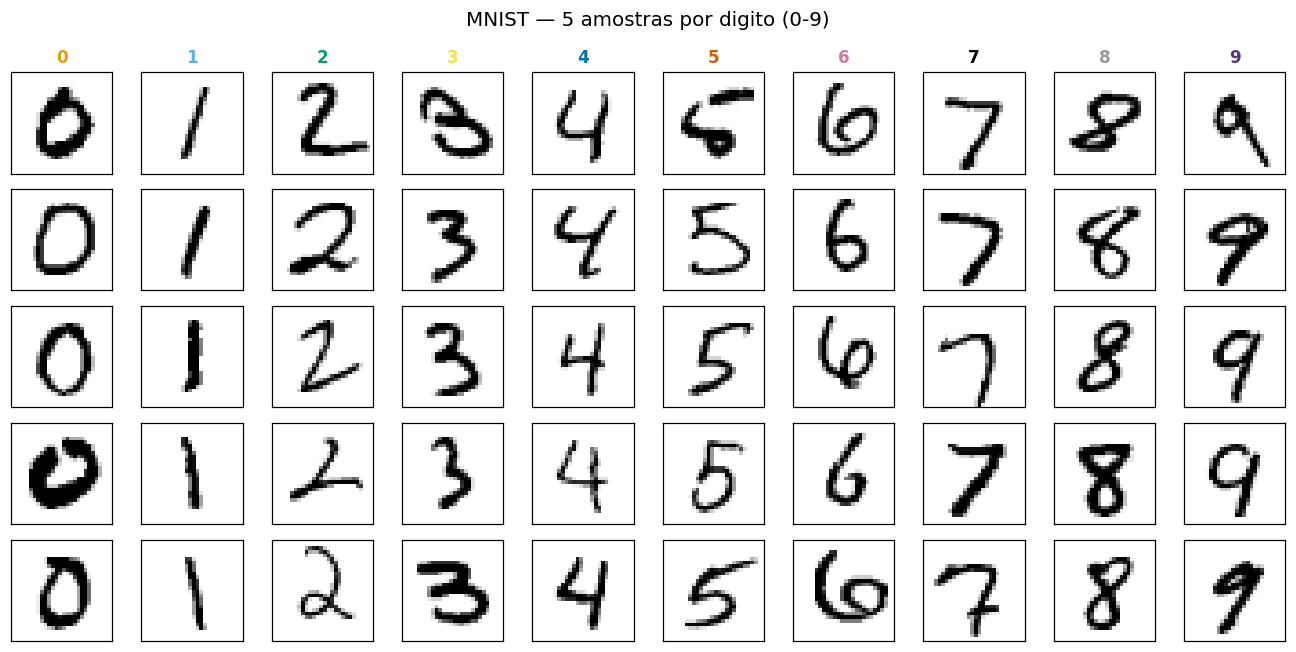

In [4]:
# Grade 5x10 — uma amostra dos dados
fig, axes = plt.subplots(5, 10, figsize=(12, 6))
fig.suptitle("MNIST — 5 amostras por digito (0-9)", fontsize=13)
for c in range(10):
    idx_c = np.where(y_eval == c)[0][:5]
    for row, i in enumerate(idx_c):
        ax = axes[row, c]
        ax.imshow(X_eval[i], cmap="gray_r", interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(str(c), fontsize=11, color=CORES[c], fontweight="bold")
plt.tight_layout()
plt.show()

---
## Parte 1 — O espaco de pixels cru e dificil de interpretar

Cada imagem MNIST e um vetor de **784 dimensoes** (28 x 28 pixels).
Sera que a distancia euclidiana nesse espaco reflete similaridade
entre digitos? Vamos verificar.

/home/dlopez/tmp/pip-tmp/ipykernel_1002111/2805040676.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


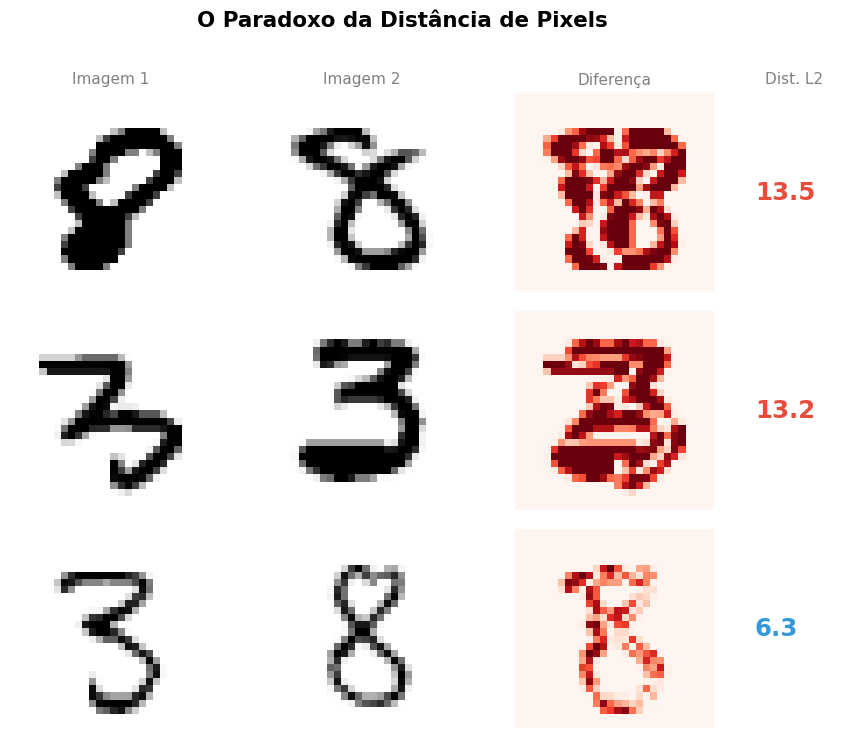

In [ ]:
rng_part1 = np.random.default_rng(0)
X_p1, y_p1 = subset_balanceado(X_eval, y_eval, 100, rng_part1)

# 1. Cálculo Compacto das Distâncias
X_flat = X_p1.reshape(len(X_p1), -1)
idx_3, idx_8 = np.where(y_p1 == 3)[0], np.where(y_p1 == 8)[0]
X3, X8 = X_flat[idx_3], X_flat[idx_8]

# Maiores distâncias intra-classe (8-8 e 3-3)
d88 = np.linalg.norm(X8[:, None] - X8[None, :], axis=-1); np.fill_diagonal(d88, 0)
i8a, i8b = np.unravel_index(d88.argmax(), d88.shape)
im8a, im8b = X_p1[idx_8[i8a]], X_p1[idx_8[i8b]]

d33 = np.linalg.norm(X3[:, None] - X3[None, :], axis=-1); np.fill_diagonal(d33, 0)
i3a, i3b = np.unravel_index(d33.argmax(), d33.shape)
im3a, im3b = X_p1[idx_3[i3a]], X_p1[idx_3[i3b]]

# Menor distância inter-classe (3-8)
d38 = np.linalg.norm(X3[:, None] - X8[None, :], axis=-1)
i3c, i8c = np.unravel_index(d38.argmin(), d38.shape)
im3c, im8c = X_p1[idx_3[i3c]], X_p1[idx_8[i8c]]

# Mapas de diferença com escala unificada
diff88, diff33, diff38 = np.abs(im8a - im8b), np.abs(im3a - im3b), np.abs(im3c - im8c)
vmax = max(diff88.max(), diff33.max(), diff38.max())

# 2. Plotagem Minimalista com GridSpec
fig = plt.figure(figsize=(10, 7.5))
gs = fig.add_gridspec(3, 4, wspace=0.05, hspace=0.1, width_ratios=[1, 1, 1, 0.4])

rows = [
    ("Dois '8's distantes", im8a, im8b, diff88, d88[i8a, i8b], "#e74c3c"),
    ("Dois '3's distantes", im3a, im3b, diff33, d33[i3a, i3b], "#e74c3c"),
    ("'3' e '8' próximos",  im3c, im8c, diff38, d38[i3c, i8c], "#3498db")
]

for r, (title, i1, i2, diff, dist, color) in enumerate(rows):
    # Coluna 1: Imagem 1
    ax1 = fig.add_subplot(gs[r, 0])
    ax1.imshow(i1, cmap="gray_r"); ax1.axis('off')
    ax1.set_ylabel(title, rotation=90, labelpad=15, fontsize=11, fontweight='bold')
    
    # Coluna 2: Imagem 2
    ax2 = fig.add_subplot(gs[r, 1])
    ax2.imshow(i2, cmap="gray_r"); ax2.axis('off')
    
    # Coluna 3: Mapa de Diferença
    axd = fig.add_subplot(gs[r, 2])
    axd.imshow(diff, cmap="Reds", vmax=vmax); axd.axis('off')
    
    # Coluna 4: Valor da Distância
    axt = fig.add_subplot(gs[r, 3])
    axt.axis('off')
    axt.text(0.1, 0.5, f"{dist:.1f}", fontsize=16, fontweight='bold', color=color, ha='left', va='center')
    
    # Títulos das colunas (apenas na primeira linha)
    if r == 0:
        for ax, t in zip([ax1, ax2, axd, axt], ["Imagem 1", "Imagem 2", "Diferença", "Dist. L2"]):
            ax.set_title(t, fontsize=10, color='gray')

fig.suptitle("O Paradoxo da Distância de Pixels", fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

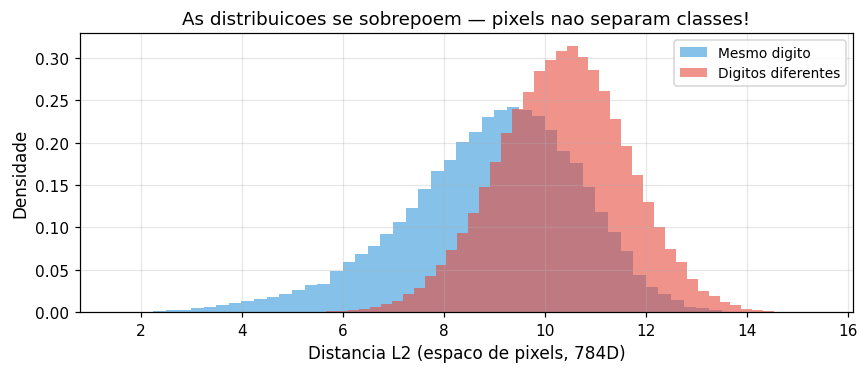

In [6]:
# Distribuicao sistematica: intra-classe vs inter-classe
n_amostra = 1000
idx_s = rng_part1.choice(len(X_p1), n_amostra, replace=False)
X_flat_p1 = X_p1.reshape(len(X_p1), -1)
X_s = X_flat_p1[idx_s]
y_s = y_p1[idx_s]

dists_todos = np.linalg.norm(X_s[:, None] - X_s[None, :], axis=-1)

intra, inter = [], []
for i in range(n_amostra):
    for j in range(i + 1, n_amostra):
        if y_s[i] == y_s[j]:
            intra.append(dists_todos[i, j])
        else:
            inter.append(dists_todos[i, j])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(intra, bins=50, alpha=0.6, label="Mesmo digito", color="#3498db", density=True)
ax.hist(inter, bins=50, alpha=0.6, label="Digitos diferentes", color="#e74c3c", density=True)
ax.set_xlabel("Distancia L2 (espaco de pixels, 784D)")
ax.set_ylabel("Densidade")
ax.set_title("As distribuicoes se sobrepoem — pixels nao separam classes!")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Resumo da Parte 1:** o espaco de pixels (784D) e enganoso.
Distancia euclidiana nele nao reflete similaridade semantica.
Duas imagens do mesmo digito podem estar mais longe que duas de
digitos diferentes. Precisamos de um **espaco latente** melhor.

---
## Parte 2 — Um espaco latente 2D emerge de um classificador

Vamos construir um **encoder CNN** que comprime a imagem 28x28
para apenas **2 numeros** (coordenadas latentes), seguido de uma
cabeca de classificacao (2D $\to$ 10 classes).

Se o bottleneck funcionar, todas as informacoes sobre o digito
passam por esses 2 numeros — e as classes devem se separar no
espaco 2D.

In [7]:
# Arquitetura: CNN encoder com bottleneck 2D

class Encoder(eqx.Module):
    """CNN encoder: imagem (1,28,28) -> vetor latente (dim_latente,)."""
    conv1: eqx.nn.Conv2d
    conv2: eqx.nn.Conv2d
    fc1: eqx.nn.Linear
    fc_out: eqx.nn.Linear

    def __init__(self, dim_latente, key):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.conv1 = eqx.nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, key=k1)
        self.conv2 = eqx.nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, key=k2)
        # Apos conv2: (32, 7, 7) -> flatten -> 1568
        self.fc1 = eqx.nn.Linear(32 * 7 * 7, 64, key=k3)
        self.fc_out = eqx.nn.Linear(64, dim_latente, key=k4)

    def __call__(self, x):
        x = jax.nn.relu(self.conv1(x))    # (16, 14, 14)
        x = jax.nn.relu(self.conv2(x))    # (32, 7, 7)
        x = x.reshape(-1)                 # (1568,)
        x = jax.nn.relu(self.fc1(x))      # (64,)
        return self.fc_out(x)             # (dim_latente,)


class Classificador(eqx.Module):
    """Encoder 2D + cabeca de classificacao (2D -> 10 classes)."""
    encoder: Encoder
    head: eqx.nn.Linear

    def __init__(self, key):
        k1, k2 = jax.random.split(key)
        self.encoder = Encoder(dim_latente=2, key=k1)
        self.head = eqx.nn.Linear(2, 10, key=k2)

    def __call__(self, x):
        z = self.encoder(x)   # bottleneck 2D
        return self.head(z)   # logits (10,)


# Criar modelo
KEY, k_modelo = jax.random.split(KEY)
classificador = Classificador(key=k_modelo)

# Teste de shape
x_teste = jnp.zeros((1, 28, 28))
z_teste = classificador.encoder(x_teste)
logits_teste = classificador(x_teste)
n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(classificador, eqx.is_array)))
print(f"Encoder: (1, 28, 28) -> {z_teste.shape}  (bottleneck 2D)")
print(f"Classificador: (1, 28, 28) -> {logits_teste.shape}  (logits)")
print(f"Parametros totais: {n_params:,}")

Encoder: (1, 28, 28) -> (2,)  (bottleneck 2D)
Classificador: (1, 28, 28) -> (10,)  (logits)
Parametros totais: 105,376


In [ ]:
# Preparar dados no formato CNN e definir funcoes de treino

# Formato CNN: (N, 1, 28, 28) como JAX arrays
X_train_cnn = jnp.array(X_train[:, None])
y_train_jnp = jnp.array(y_train)

# Conjunto de avaliacao completo (10k) — carregado em batches para plots
X_eval_cnn = jnp.array(X_eval[:, None])
y_eval_jnp = jnp.array(y_eval)

N_TRAIN = len(X_train)
BATCH_SUP = 128

def perda_ce(modelo, x_batch, y_batch):
    """Entropia cruzada (cross-entropy)."""
    logits = jax.vmap(modelo)(x_batch)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y_batch).mean()

otimizador_sup = optax.adam(learning_rate=2e-3)
opt_state_sup = otimizador_sup.init(eqx.filter(classificador, eqx.is_array))

@eqx.filter_jit
def passo_sup(modelo, opt_state, x, y):
    """Um passo de treino supervisionado."""
    perda, grads = eqx.filter_value_and_grad(perda_ce)(modelo, x, y)
    updates, opt_state = otimizador_sup.update(grads, opt_state, modelo)
    modelo = eqx.apply_updates(modelo, updates)
    return modelo, opt_state, perda

print(f"Treino   : {N_TRAIN:,} imagens")
print(f"Avaliacao: {len(X_eval):,} imagens (scatter plots)")
print(f"Batch: {BATCH_SUP}   Otimizador: Adam (lr=2e-3)")

Treino   : 2,000 imagens
Avaliacao: 10,000 imagens (scatter plots)
Batch: 128   Otimizador: Adam (lr=2e-3)


In [ ]:
# Treino supervisionado
N_EPOCAS_SUP = 60
historico_sup = []
chave_sup = jax.random.PRNGKey(1)

print(f"Treinando classificador ({N_EPOCAS_SUP} epocas)...")

for epoca in range(1, N_EPOCAS_SUP + 1):
    chave_sup, k_perm = jax.random.split(chave_sup)
    perm = jax.random.permutation(k_perm, N_TRAIN)

    for i in range(0, N_TRAIN, BATCH_SUP):
        idx = perm[i:i + BATCH_SUP]
        classificador, opt_state_sup, _ = passo_sup(classificador, opt_state_sup, X_train_cnn[idx], y_train_jnp[idx])

    # Perda no treino
    p_tr = float(perda_ce(classificador, X_train_cnn, y_train_jnp))
    historico_sup.append((epoca, p_tr))
    if epoca % 10 == 0 or epoca == 1:
        print(f"  Epoca {epoca:2d}  treino={p_tr:.4f}")

print("Treino concluido.")

Treinando classificador (60 epocas)...


2026-07-20 15:10:34.993249: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-20 15:10:36.516145: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


  Epoca  1  treino=2.0572
  Epoca 10  treino=1.0778
  Epoca 20  treino=0.5731
  Epoca 30  treino=0.1499
  Epoca 40  treino=0.0623
  Epoca 50  treino=0.0274
  Epoca 60  treino=0.0078
Treino concluido.


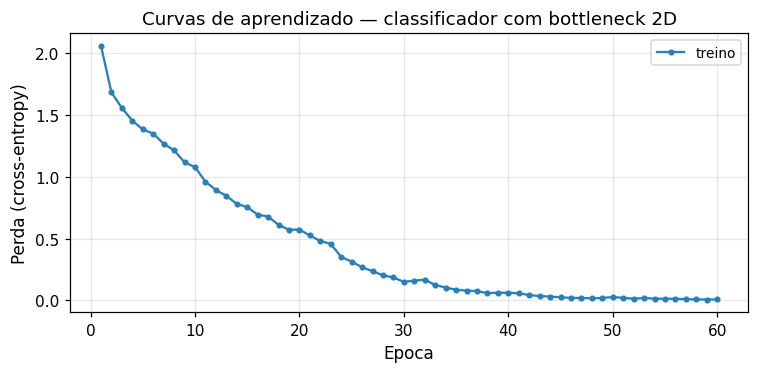

In [10]:
# Curvas de aprendizado
epocas, l_tr = zip(*historico_sup)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epocas, l_tr, "-o", ms=3, lw=1.5, color="#2980b9", label="treino")
ax.set_xlabel("Epoca")
ax.set_ylabel("Perda (cross-entropy)")
ax.set_title("Curvas de aprendizado — classificador com bottleneck 2D")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

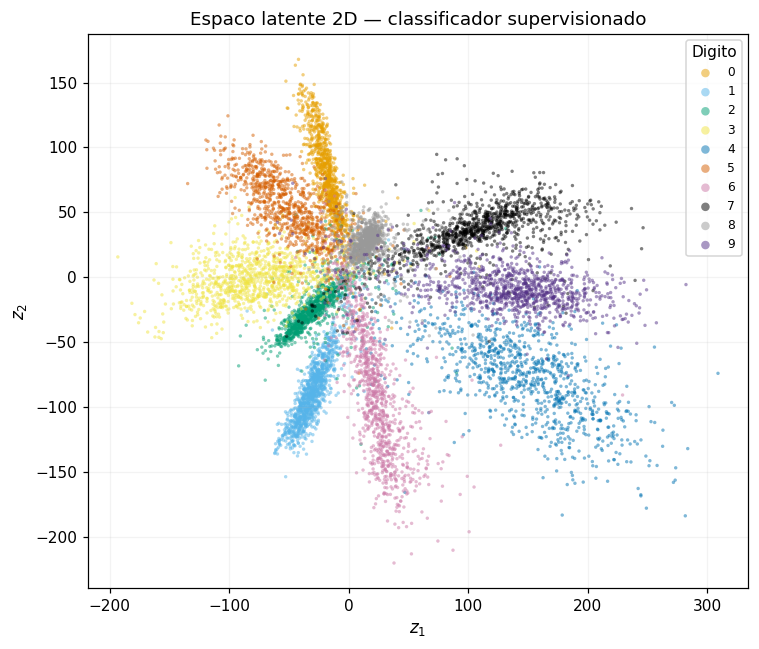

Scatter com 10,000 pontos — cada ponto e uma imagem do teste.
As classes se separam — o bottleneck aprendeu coordenadas uteis!


In [ ]:
def obter_embeddings(encoder, X_cnn, batch_sz=512):
    """Calcula embeddings em lotes. X_cnn: JAX array (N, 1, 28, 28)."""
    partes = []
    for i in range(0, len(X_cnn), batch_sz):
        partes.append(np.array(jax.vmap(encoder)(X_cnn[i:i + batch_sz])))
    return np.concatenate(partes)

Z_sup = obter_embeddings(classificador.encoder, X_eval_cnn)

fig, ax = plt.subplots(figsize=(7, 6))
for c in range(10):
    mask = y_eval == c
    ax.scatter(Z_sup[mask, 0], Z_sup[mask, 1], s=5, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("Espaco latente 2D — classificador supervisionado", fontsize=12)
ax.legend(title="Digito", fontsize=8, markerscale=2.5, framealpha=0.8)
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

print(f"Scatter com {len(Z_sup):,} pontos — cada ponto e uma imagem do teste. As classes se separam — o bottleneck aprendeu coordenadas uteis!")

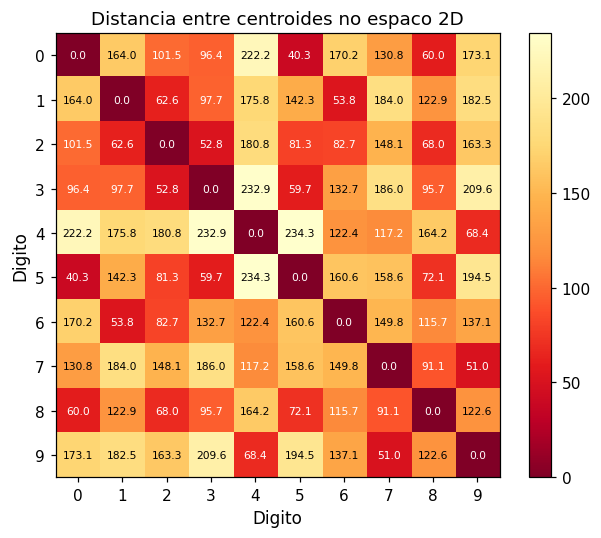

Pares de digitos mais proximos no espaco latente:
  0 e 5: distancia = 40.27
  7 e 9: distancia = 51.01
  2 e 3: distancia = 52.80
  1 e 6: distancia = 53.76

Faz sentido? Digitos visualmente parecidos ficam proximos!


In [ ]:
# Quais classes ficam proximas? Distancia entre centroides

centroides = np.array([Z_sup[y_eval == c].mean(axis=0) for c in range(10)])
dist_centroides = np.linalg.norm(centroides[:, None] - centroides[None, :], axis=-1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dist_centroides, cmap="YlOrRd_r", interpolation="nearest")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Digito"); ax.set_ylabel("Digito")
ax.set_title("Distancia entre centroides no espaco 2D")
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{dist_centroides[i, j]:.1f}", ha="center", va="center", fontsize=7,
            color="white" if dist_centroides[i, j] < dist_centroides.max() * 0.5 else "black")
plt.tight_layout()
plt.show()

# Encontrar os pares mais proximos
pares = []
for i in range(10):
    for j in range(i + 1, 10):
        pares.append((dist_centroides[i, j], i, j))
pares.sort()
print("Pares de digitos mais proximos no espaco latente:")
for d, i, j in pares[:4]:
    print(f"  {i} e {j}: distancia = {d:.2f}")

**O que aprendemos:** o encoder encontrou coordenadas 2D. Geralmente classes
similares ficam proximas. A estrutura emerge do treino supervisionado
sem os rotulos disseram quem deve ficar perto de quem.

**Pergunta:** e possivel obter essa estrutura
**sem usar nenhum rotulo**?

---
## Parte 3 — Augmentacoes como declaracoes de invariancia

Na aprendizagem contrastiva auto-supervisionada, os **pares positivos**
vem de **augmentacoes**: duas versoes distorcidas da mesma imagem sao
declaradas como "o mesmo objeto."

Cada augmentacao e uma afirmacao:
> "Esta transformacao **nao deve mudar** a identidade do objeto."

Ou, na linguagem da fisica: cada augmentacao declara uma **simetria**
que o encoder deve respeitar.

### Por que augmentacoes fortes sao essenciais

A literatura mostra que augmentacoes **fracas** (so ruido + pequena
translacao) permitem que o encoder aprenda **atalhos** (*shortcuts*):
em vez de capturar a forma global do digito (neste caso), a rede explora a posicao
absoluta ou a tinta total para distinguir pares positivos dos negativos,
sem jamais aprender semantica.

Nossa pipeline combina: deformacao elastica + transformacao afim
(rotacao, cisalhamento, escala) + blur + ruido + cutout.

In [ ]:
# ==============================================================================
# Pipeline de augmentacoes FORTE para MNIST
# ==============================================================================
from scipy.ndimage import (gaussian_filter, map_coordinates, affine_transform as scipy_affine, grey_dilation, grey_erosion, zoom as nd_zoom)

FORCA = 1.0   # dial global de intensidade: 0.5 = suave, 1.0 = forte, 1.5 = extrema

def deformacao_elastica(img, rng, alpha=(4.0, 9.0), sigma=(3.0, 4.5)):
    """Deformacao elastica (Simard et al. 2003), com amplitude aleatoria.
    Campos de deslocamento aleatorios suavizados por gaussiana, reamostrados
    com interpolacao bilinear. Emula oscilacoes involuntarias da mao."""
    a = rng.uniform(*alpha) * FORCA
    s = rng.uniform(*sigma)
    dx = gaussian_filter(rng.uniform(-1, 1, img.shape), s) * a
    dy = gaussian_filter(rng.uniform(-1, 1, img.shape), s) * a
    yy, xx = np.mgrid[0:img.shape[0], 0:img.shape[1]]
    return map_coordinates(img, [yy + dy, xx + dx], order=1, mode="constant", cval=0.0).astype(np.float32)

def transformacao_afim(img, rng, max_angulo=25, max_shear=0.20, escala=(0.75, 1.25), max_trans=4):
    """Rotacao + cisalhamento + escala independente em x/y + translacao.
    max_angulo <= ~25 graus: invariancia deliberadamente LIMITADA, para nao
    transformar um 6 em 9 (a escolha da augmentacao e uma escolha de fisica)."""
    h, w = img.shape
    ang = np.deg2rad(rng.uniform(-max_angulo, max_angulo) * FORCA)
    shear = rng.uniform(-max_shear, max_shear) * FORCA
    sx, sy = rng.uniform(*escala, size=2)
    tx, ty = rng.uniform(-max_trans, max_trans, size=2) * FORCA
    R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
    S = np.array([[1.0 / sx, shear], [0.0, 1.0 / sy]])
    M = S @ R
    offset = np.array([h / 2, w / 2]) - M @ np.array([h / 2 + ty, w / 2 + tx])
    return scipy_affine(img, M, offset=offset, order=1, mode="constant", cval=0.0).astype(np.float32)

def recorte_redimensionado(img, rng, escala=(0.45, 1.0), razao=(0.8, 1.25)):
    """Random resized crop: recorta uma sub-regiao aleatoria e reamostra para 28x28.
    E a augmentacao MAIS eficaz identificada pelo SimCLR — obriga a rede a usar a
    forma global, e nao um traco local, para reconhecer a mesma instancia."""
    h, w = img.shape
    area = rng.uniform(escala[0] / max(FORCA, 1e-6), escala[1])
    r = np.exp(rng.uniform(np.log(razao[0]), np.log(razao[1])))
    ch, cw = np.clip([np.sqrt(area / r) * h, np.sqrt(area * r) * w], 4, [h, w])
    y0, x0 = rng.uniform(0, h - ch), rng.uniform(0, w - cw)
    yy, xx = np.mgrid[0:h, 0:w]
    coords = [y0 + yy * (ch - 1) / (h - 1), x0 + xx * (cw - 1) / (w - 1)]
    return map_coordinates(img, coords, order=1, mode="constant", cval=0.0).astype(np.float32)

def espessura_traco(img, rng):
    """Dilata ou erode o traco: emula canetas de espessuras diferentes.
    Invariancia genuinamente relevante em digitos manuscritos."""
    k = int(rng.integers(2, 4))
    return (grey_dilation(img, size=k) if rng.random() < 0.5 else grey_erosion(img, size=k)).astype(np.float32)

def jitter_intensidade(img, rng):
    """Brilho, contraste e gamma — o substituto em escala de cinza do
    'color jitter' do SimCLR, indisponivel em imagens monocromaticas."""
    img = img * rng.uniform(0.7, 1.3) + rng.uniform(-0.12, 0.12) * FORCA
    return np.clip(img, 0, 1) ** rng.uniform(0.6, 1.6)

def blur_gaussiano(img, rng, sigma_max=1.4):
    return gaussian_filter(img, rng.uniform(0.4, sigma_max * FORCA)).astype(np.float32)

def pixelizacao(img, rng):
    """Reduz e restaura a resolucao: destroi detalhe fino do traco."""
    f = rng.uniform(0.35, 0.65)
    peq = nd_zoom(img, f, order=1)
    return nd_zoom(peq, (img.shape[0] / peq.shape[0], img.shape[1] / peq.shape[1]), order=1)[:28, :28].astype(np.float32)

def cutout(img, rng, n_max=2, tam_max=10):
    """Random erasing: apaga 1-2 retangulos. Impede que a rede se apoie em uma
    unica regiao do digito para identificar a instancia."""
    out = img.copy()
    for _ in range(rng.integers(1, n_max + 1)):
        th, tw = rng.integers(4, int(tam_max * FORCA) + 1, size=2)
        y0, x0 = rng.integers(0, 28 - th), rng.integers(0, 28 - tw)
        out[y0:y0 + th, x0:x0 + tw] = 0.0
    return out

def ruido(img, rng):
    """Ruido gaussiano aditivo + sal-e-pimenta esparso."""
    out = img + rng.normal(0, 0.09 * FORCA, img.shape)
    mask = rng.random(img.shape) < 0.01 * FORCA
    out[mask] = rng.random(mask.sum())
    return out.astype(np.float32)

POOL = [espessura_traco, jitter_intensidade, blur_gaussiano, pixelizacao, cutout, ruido]

def augmentar_imagem(img, rng, n_ops=3):
    """Pipeline composta FORTE.
    Nucleo geometrico (sempre): elastica -> afim -> recorte redimensionado.
    Pool estocastico: n_ops operacoes sorteadas SEM reposicao, em ordem aleatoria
    (composicao ao estilo RandAugment/SimCLR). Duas vistas da mesma ancora diferem
    portanto em QUAIS transformacoes sofreram, e nao apenas na intensidade delas.
    Salvaguarda: se o digito for destruido (tinta residual < 20% da original),
    reamostra a augmentacao ate 3 vezes."""
    img = np.asarray(img, dtype=np.float32)
    tinta_orig = img.sum()

    for _ in range(3):
        out = recorte_redimensionado(
            transformacao_afim(deformacao_elastica(img, rng), rng), rng)
        for op in rng.permutation(POOL)[:n_ops]:
            out = op(out, rng)
        out = np.clip(out, 0, 1).astype(np.float32)
        if out.sum() > 0.20 * tinta_orig:      # o digito sobreviveu
            return out
    return out

def augmentar_batch(X_batch, rng, n_ops=3):
    return np.stack([augmentar_imagem(x, rng, n_ops) for x in X_batch])

Pipeline de augmentacoes FORTE (composicao estocastica):
  NUCLEO (sempre): elastica -> afim (rot+-25, shear, escala x/y, transl.)
                   -> recorte redimensionado (crop: a mais eficaz do SimCLR)
  POOL (sorteia 3 de 6): espessura do traco, jitter de intensidade/gamma,
                   blur, pixelizacao, cutout (1-2 patches), ruido+sal-e-pimenta
  FORCA = 1.0  ·  salvaguarda: rejeita vistas que apagam o digito


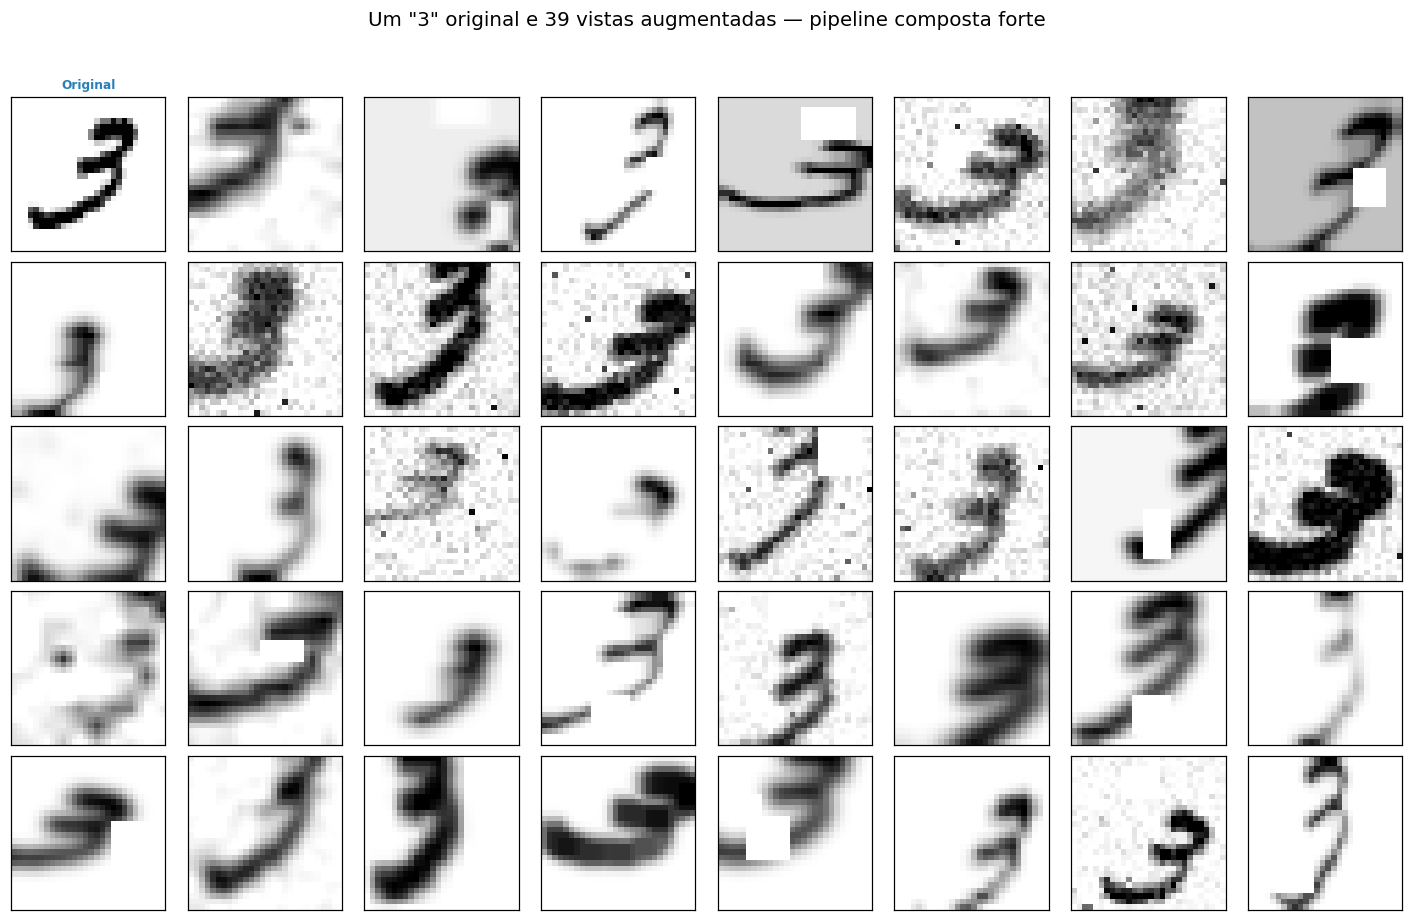

As distorcoes sao FORTES: elastica + afim + blur + ruido + cutout.
O digito continua legivel, mas atalhos (posicao, tinta total) sao destruidos.


In [ ]:
rng_aug_viz = np.random.default_rng(7)
idx_demo_aug = np.where(y_train == 3)[0][2]
img_demo = X_train[idx_demo_aug]

n_linhas, n_colunas = 5, 8  # 40 vistas
fig, axes = plt.subplots(n_linhas, n_colunas, figsize=(13, 8.5))
fig.suptitle('Um "3" original e 39 vistas augmentadas — pipeline composta forte', fontsize=13, y=0.98)

# Primeiro slot: original
axes[0, 0].imshow(img_demo, cmap="gray_r", interpolation="nearest")
axes[0, 0].set_title("Original", fontsize=8, fontweight="bold", color="#2980b9")

# Vistas augmentadas
for k in range(1, n_linhas * n_colunas):
    row, col = divmod(k, n_colunas)
    vista = augmentar_imagem(img_demo, rng_aug_viz)
    axes[row, col].imshow(vista, cmap="gray_r", interpolation="nearest")

for ax_row in axes:
    for ax in ax_row:
        ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

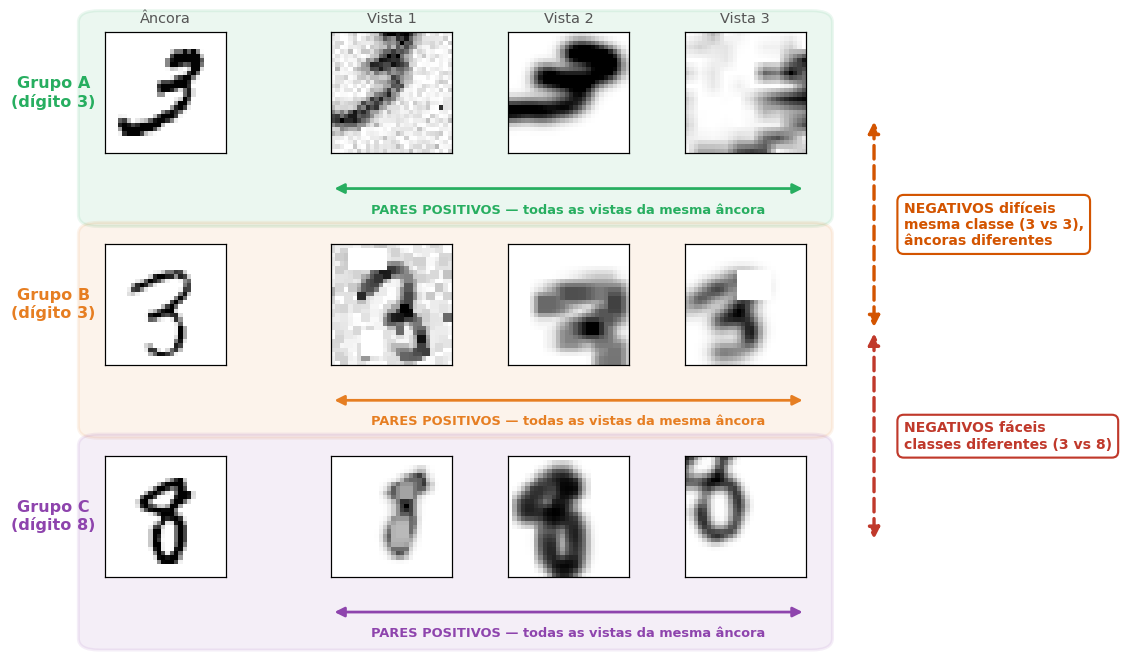

In [ ]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

rng = np.random.default_rng(42)
idx3, idx8 = np.where(y_train == 3)[0], np.where(y_train == 8)[0]

grupos = [("Grupo A", "dígito 3", X_train[idx3[2]],  "#27ae60"),
          ("Grupo B", "dígito 3", X_train[idx3[15]], "#e67e22"),
          ("Grupo C", "dígito 8", X_train[idx8[0]],  "#8e44ad")]
N_VISTAS = 3

fig = plt.figure(figsize=(13.5, 7.5))
gs = fig.add_gridspec(3, 5, width_ratios=[1, 0.22, 1, 1, 1], left=0.10, right=0.60, top=0.86, bottom=0.20, wspace=0.10, hspace=0.75)

eixos = {}
for r, (nome, classe, ancora, cor) in enumerate(grupos):
    for c in range(-1, N_VISTAS):                      # c = -1 -> âncora original
        ax = fig.add_subplot(gs[r, 0 if c < 0 else c + 2])
        ax.imshow(ancora if c < 0 else augmentar_imagem(ancora, rng), cmap="gray_r", interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zorder(2)
        if r == 0:
            ax.set_title("Âncora" if c < 0 else f"Vista {c+1}", fontsize=9.5, color="#555", pad=6)
        if c < 0:
            ax.set_ylabel(f"{nome}\n({classe})", rotation=0, fontsize=10.5, fontweight="bold", color=cor, labelpad=34, ha="center", va="center")
        eixos[(r, c)] = ax

fig.canvas.draw()   # imshow usa aspect='equal': posições só são válidas após o draw

# --- caixas de grupo = pares POSITIVOS -----------------------------------------
caixas = {}
for r, (_, _, _, cor) in enumerate(grupos):
    ps = [eixos[(r, c)].get_position() for c in range(-1, N_VISTAS)]
    x0, x1 = min(p.x0 for p in ps) - 0.014, max(p.x1 for p in ps) + 0.014
    y0, y1 = min(p.y0 for p in ps) - 0.085, max(p.y1 for p in ps) + 0.022
    caixas[r] = (x0, y0, x1, y1)

    fig.add_artist(FancyBboxPatch((x0, y0), x1 - x0, y1 - y0,
        boxstyle="round,pad=0.004,rounding_size=0.014", transform=fig.transFigure,
        facecolor=cor, alpha=0.09, edgecolor=cor, linewidth=2, zorder=0))

    xa = eixos[(r, 0)].get_position().x0
    xb = eixos[(r, N_VISTAS - 1)].get_position().x1
    y = y0 + 0.042
    fig.add_artist(FancyArrowPatch((xa, y), (xb, y), transform=fig.transFigure, arrowstyle="<|-|>", mutation_scale=13, color=cor, linewidth=1.8, zorder=3))
    fig.text((xa + xb) / 2, y - 0.030, "PARES POSITIVOS — todas as vistas da mesma âncora", ha="center", fontsize=8.5, fontweight="bold", color=cor)

# --- setas entre caixas = pares NEGATIVOS --------------------------------------
x = max(c[2] for c in caixas.values()) + 0.032
for ra, rb, cor, txt in [
        (0, 1, "#d35400", "NEGATIVOS difíceis\nmesma classe (3 vs 3),\nâncoras diferentes"),
        (1, 2, "#c0392b", "NEGATIVOS fáceis\nclasses diferentes (3 vs 8)")]:
    ya, yb = [(caixas[r][1] + caixas[r][3]) / 2 for r in (ra, rb)]
    fig.add_artist(FancyArrowPatch((x, ya), (x, yb), transform=fig.transFigure,
        arrowstyle="<|-|>", mutation_scale=15, color=cor, linewidth=2.2,
        linestyle=(0, (4, 2)), zorder=3))
    fig.text(
        x + 0.020, (ya + yb) / 2, txt, ha="left", va="center", fontsize=9.2, fontweight="bold",
        color=cor, bbox=dict(boxstyle="round,pad=0.45", facecolor="white", edgecolor=cor, linewidth=1.4)
    )

plt.show()

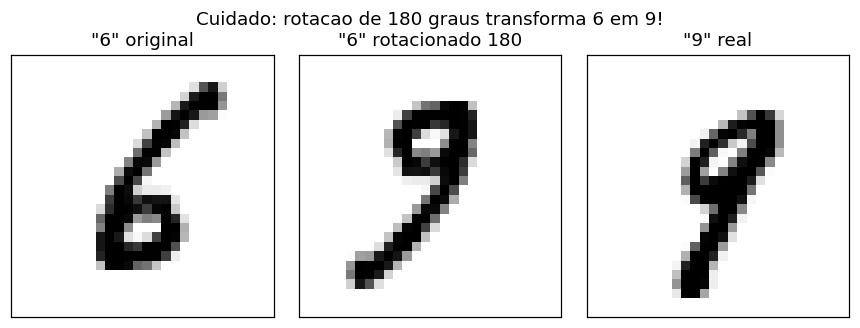

A escolha de augmentacoes e parte do design do modelo.
Nossas rotacoes sao limitadas a +-25 graus — uma decisao de
invariancia ESPECIFICA DO DOMINIO que preserva a distincao 6/9.
Rotacoes maiores destruiriam a classe — uma invariancia ERRADA.


In [ ]:
# Exemplo cautelar: augmentacao agressiva demais pode destruir o rotulo!
idx_6 = np.where(y_train == 6)[0][5]
img_6 = X_train[idx_6]
img_6_rot180 = img_6[::-1, ::-1]  # rotacao de 180 graus

idx_9 = np.where(y_train == 9)[0][0]
img_9 = X_train[idx_9]

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
fig.suptitle("Cuidado: rotacao de 180 graus transforma 6 em 9!", fontsize=12)
axes[0].imshow(img_6, cmap="gray_r"); axes[0].set_title('"6" original')
axes[1].imshow(img_6_rot180, cmap="gray_r"); axes[1].set_title('"6" rotacionado 180')
axes[2].imshow(img_9, cmap="gray_r"); axes[2].set_title('"9" real')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

**Resumo da Parte 3:** cada augmentacao tem que declarar uma invariancia.

**O design das augmentacoes e parte do design do modelo.**
Uma augmentacao mal escolhida planta invariancias erradas.

---
## Parte 4 — Treinar com InfoNCE e recuperar a estrutura SEM rotulos

A perda InfoNCE e:

$$\mathcal{L}_\text{InfoNCE} = -\log \frac{\exp\!\bigl(\text{sim}(\mathbf{z}_i, \mathbf{z}_j)/\tau\bigr)}{\displaystyle\sum_{k \neq i} \exp\!\bigl(\text{sim}(\mathbf{z}_i, \mathbf{z}_k)/\tau\bigr)}$$

onde $\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}^\top \mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$
e a similaridade cosseno e $\tau > 0$ e a **temperatura**.

### Arquitetura SimCLR: representacao $h$ e cabeca de projecao $z$

Na pratica (Chen et al. 2020, SimCLR), a InfoNCE **nao** e aplicada
diretamente sobre um embedding 2D — isso seria uma restricao severa
demais. O protocolo padrao usa dois estagios:

1. **Encoder** $f_\theta$: imagem $\to$ representacao $\mathbf{h}$
   (dimensao moderada, e.g. 64D)
2. **Cabeca de projecao** $g_\phi$: $\mathbf{h} \to \mathbf{z}$
   (MLP pequeno; $\mathbf{z}$ e normalizado na esfera unitaria)

A perda InfoNCE e computada sobre $\mathbf{z}$, mas **apos o treino
descartamos a cabeca** e usamos $\mathbf{h}$ como representacao final.

**Por que?** A cabeca absorve informacao especifica da tarefa pretexto
(invariancias das augmentacoes), enquanto $\mathbf{h}$ retem mais
informacao geral — e por isso transfere melhor para tarefas downstream
(Chen et al. 2020, Sec. 4.2).

In [ ]:
# Encoder SSL reforçado: 3 camadas conv

class EncoderSSL(eqx.Module):
    """CNN encoder reforcado para a tarefa contrastiva.
    Tres camadas convolucionais + FC -> representacao h.
    Mais capacidade que o Encoder da Parte 2, mas ainda leve para CPU.
    """
    conv1: eqx.nn.Conv2d
    conv2: eqx.nn.Conv2d
    conv3: eqx.nn.Conv2d
    fc1: eqx.nn.Linear
    fc_out: eqx.nn.Linear

    def __init__(self, dim_h, key):
        k1, k2, k3, k4, k5 = jax.random.split(key, 5)
        self.conv1 = eqx.nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1, key=k1)
        self.conv2 = eqx.nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1, key=k2)
        self.conv3 = eqx.nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, key=k3)
        # Apos conv3: (128, 4, 4) -> flatten -> 2048
        self.fc1 = eqx.nn.Linear(128 * 4 * 4, 128, key=k4)
        self.fc_out = eqx.nn.Linear(128, dim_h, key=k5)

    def __call__(self, x):
        x = jax.nn.relu(self.conv1(x))    # (32, 14, 14)
        x = jax.nn.relu(self.conv2(x))    # (64, 7, 7)
        x = jax.nn.relu(self.conv3(x))    # (128, 4, 4)
        x = x.reshape(-1)                 # (2048,)
        x = jax.nn.relu(self.fc1(x))      # (128,)
        return self.fc_out(x)             # (dim_h,)


class CabecaProjecao(eqx.Module):
    """MLP de projecao: h -> z (normalizado L2).
    Chen et al. 2020 mostram que um MLP nao-linear aqui
    melhora substancialmente a qualidade da representacao.
    """
    fc1: eqx.nn.Linear
    fc2: eqx.nn.Linear

    def __init__(self, dim_h, dim_z, key):
        k1, k2 = jax.random.split(key)
        self.fc1 = eqx.nn.Linear(dim_h, dim_h, key=k1)
        self.fc2 = eqx.nn.Linear(dim_h, dim_z, key=k2)

    def __call__(self, h):
        z = jax.nn.relu(self.fc1(h))
        z = self.fc2(z)
        # Normalizacao L2 -> esfera unitaria
        return z / (jnp.linalg.norm(z) + 1e-8)


class ModeloContrastivo(eqx.Module):
    """Encoder + cabeca de projecao (SimCLR-style)."""
    encoder: EncoderSSL
    head: CabecaProjecao

    def __init__(self, dim_h, dim_z, key):
        k1, k2 = jax.random.split(key)
        self.encoder = EncoderSSL(dim_h, key=k1)
        self.head = CabecaProjecao(dim_h, dim_z, key=k2)

    def __call__(self, x):
        h = self.encoder(x)       # representacao (dim_h,)
        z = self.head(h)          # projecao normalizada (dim_z,)
        return z

    def representacao(self, x):
        """Retorna h (para avaliacao downstream — sem a cabeca)."""
        return self.encoder(x)


# Hiperparametros
DIM_H = 32   # dimensao da representacao
DIM_Z = 64    # dimensao da projecao (onde InfoNCE atua)

KEY, k_ssl = jax.random.split(KEY)
modelo_ssl = ModeloContrastivo(DIM_H, DIM_Z, key=k_ssl)

# Teste de shape
x_teste = jnp.zeros((1, 28, 28))
h_teste = modelo_ssl.representacao(x_teste)
z_teste = modelo_ssl(x_teste)
n_params_ssl = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(modelo_ssl, eqx.is_array)))
print(f"Encoder SSL: (1, 28, 28) -> h {h_teste.shape}  (representacao)")
print(f"Modelo completo: (1, 28, 28) -> z {z_teste.shape}  (projecao, norma L2 = {float(jnp.linalg.norm(z_teste)):.3f})")
print(f"Parametros totais: {n_params_ssl:,}")

Encoder SSL: (1, 28, 28) -> h (32,)  (representacao)
Modelo completo: (1, 28, 28) -> z (64,)  (projecao, norma L2 = 1.000)
Parametros totais: 380,992

Apos o treino, DESCARTAMOS a cabeca de projecao.
Usamos h (64D) como representacao — ela retem mais informacao geral.


### Regime de treino:

A qualidade da InfoNCE escala com o **numero de negativos**:
cada batch de $N$ amostras fornece $2(N-1)$ negativos por ancora.
Com batch pequeno a tarefa e facil demais e o encoder nao
precisa aprender representacoes finas.
Por isso SimCLR usa batches de 4096-8192 (na GPU).
Aqui, no nosso regime didatico usamos batch=256
(fornecendo $2 \times 255 = 510$ negativos por ancora) e
compensamos com mais epocas.

In [ ]:
# Perda InfoNCE — agora opera sobre o modelo completo (encoder + head)

TAU = 0.15  # temperatura (SimCLR usa ~0.07-0.1; 0.15 e estavel para nosso regime)
BATCH_SSL = 256  # batch grande -> mais negativos

def perda_infonce(modelo, x_vista1, x_vista2):
    """
    InfoNCE sobre a projecao z (L3B1 §4.4).
    x_vista1, x_vista2: duas vistas augmentadas do mesmo batch.
    Shape: (B, 1, 28, 28).
    """
    # -- Projecoes z (ja normalizadas L2 dentro do modelo) --
    z_i = jax.vmap(modelo)(x_vista1)                            # (B, dim_z)
    z_j = jax.vmap(modelo)(x_vista2)                            # (B, dim_z)
    B = z_i.shape[0]

    # -- Todas as representacoes: 2B embeddings --
    z = jnp.concatenate([z_i, z_j], axis=0)                     # (2B, dim_z)

    # -- Similaridade cosseno (z ja normalizado) --
    sim = z @ z.T                                                # (2B, 2B)

    # -- Logits = sim / tau --
    logits = sim / TAU                                           # (2B, 2B)

    # -- Excluir auto-similaridade: diagonal -> -inf --
    logits = jnp.where(~jnp.eye(2 * B, dtype=bool), logits, -1e9)

    # -- Denominador: "funcao de particao" --
    log_denom = jax.nn.logsumexp(logits, axis=1)                 # (2B,)

    # -- Numerador: sim(z_i, z_j)/tau para o par positivo --
    idx_pos = jnp.concatenate([jnp.arange(B, 2 * B), jnp.arange(B)])
    log_num = sim[jnp.arange(2 * B), idx_pos] / TAU              # (2B,)

    # -- InfoNCE: -E[ log(numerador / denominador) ] --
    return -jnp.mean(log_num - log_denom)

Perda InfoNCE definida.
  Temperatura tau = 0.15 (SimCLR range)
  Batch = 256 -> 2x(B-1) = 510 negativos por ancora
  Nenhum rotulo de classe sera usado no treino!


In [19]:
# Treino contrastivo (mais epocas que o supervisionado — InfoNCE converge mais devagar)

otimizador_ssl = optax.adam(learning_rate=1e-3)
opt_state_ssl = otimizador_ssl.init(eqx.filter(modelo_ssl, eqx.is_array))

@eqx.filter_jit
def passo_ssl(modelo, opt_state, x_v1, x_v2):
    """Um passo de treino contrastivo (InfoNCE)."""
    perda, grads = eqx.filter_value_and_grad(perda_infonce)(modelo, x_v1, x_v2)
    updates, opt_state = otimizador_ssl.update(grads, opt_state, modelo)
    modelo = eqx.apply_updates(modelo, updates)
    return modelo, opt_state, perda

N_EPOCAS_SSL = 200
historico_ssl = []
rng_ssl = np.random.default_rng(123)

print(f"Treinando com InfoNCE ({N_EPOCAS_SSL} epocas, SEM rotulos)...")
print(f"  Batch={BATCH_SSL}, tau={TAU}, lr=1e-3, dim_h={DIM_H}, dim_z={DIM_Z}")

for epoca in range(1, N_EPOCAS_SSL + 1):
    perm = rng_ssl.permutation(N_TRAIN)
    perdas_epoca = []

    for i in range(0, N_TRAIN, BATCH_SSL):
        idx = perm[i:i + BATCH_SSL]
        if len(idx) < 8:
            continue  # batch muito pequeno para InfoNCE
        X_batch_np = X_train[idx]
        # Duas vistas augmentadas (numpy) -> converter para JAX
        v1 = jnp.array(augmentar_batch(X_batch_np, rng_ssl)[:, None])
        v2 = jnp.array(augmentar_batch(X_batch_np, rng_ssl)[:, None])
        modelo_ssl, opt_state_ssl, perda = passo_ssl(modelo_ssl, opt_state_ssl, v1, v2)
        perdas_epoca.append(float(perda))

    media = np.mean(perdas_epoca)
    historico_ssl.append((epoca, media))
    if epoca % 20 == 0 or epoca == 1:
        print(f"  Epoca {epoca:2d}  perda InfoNCE = {media:.4f}")

print("Treino contrastivo concluido.")

Treinando com InfoNCE (200 epocas, SEM rotulos)...
  Batch=256, tau=0.15, lr=1e-3, dim_h=32, dim_z=64


2026-07-20 15:10:45.721546: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-20 15:10:45.721637: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-20 15:10:45.721694: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-07-20 15:10:45.721700: W external/xla/xla/service/gpu/au

  Epoca  1  perda InfoNCE = 6.1965
  Epoca 20  perda InfoNCE = 5.2952
  Epoca 40  perda InfoNCE = 4.7351
  Epoca 60  perda InfoNCE = 4.4204
  Epoca 80  perda InfoNCE = 4.2688
  Epoca 100  perda InfoNCE = 4.1046
  Epoca 120  perda InfoNCE = 4.0301
  Epoca 140  perda InfoNCE = 3.9975
  Epoca 160  perda InfoNCE = 3.9704
  Epoca 180  perda InfoNCE = 3.9242
  Epoca 200  perda InfoNCE = 3.8043
Treino contrastivo concluido.


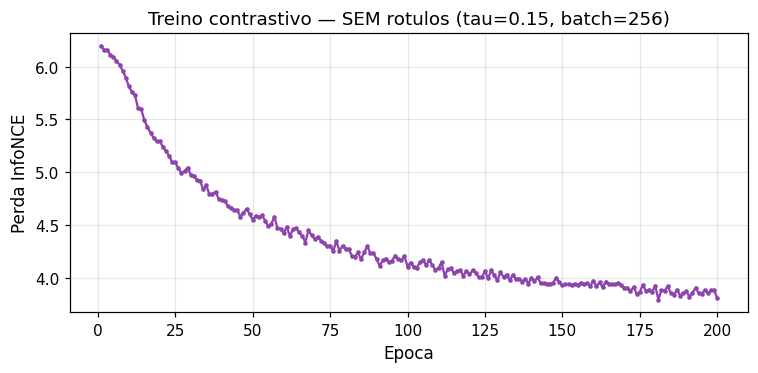

In [20]:
# Curva de perda InfoNCE
ep_ssl, l_ssl = zip(*historico_ssl)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ep_ssl, l_ssl, "-o", ms=2, lw=1.5, color="#8e44ad")
ax.set_xlabel("Epoca")
ax.set_ylabel("Perda InfoNCE")
ax.set_title(f"Treino contrastivo — SEM rotulos (tau={TAU}, batch={BATCH_SSL})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizar a representacao $h$ com t-SNE

A representacao $\mathbf{h}$ tem muitas dimensoes no geral — nao podemos plota-la
diretamente. Usamos **t-SNE** para projetar em 2D e inspecionar se
ha estrutura de clusters.

**Advertencias importantes**:
- Distancias **entre** clusters no mapa t-SNE sao largamente sem
  significado — a compressao nao-linear distorce separacoes inter-grupo.
- Tamanhos e densidades de clusters nao sao fieis.
- O mapa muda com a perplexidade e a semente aleatoria.

Usamos o t-SNE para **detectar se existe estrutura** (clusters
separados por classe), nao como medicao quantitativa.

In [21]:
# Extrair representacoes h (64D) do conjunto de avaliacao (10k pontos)
from sklearn.manifold import TSNE

def obter_representacao_h(modelo, X_cnn, batch_sz=512):
    """Calcula representacao h (antes da cabeca) em lotes."""
    partes = []
    for i in range(0, len(X_cnn), batch_sz):
        partes.append(np.array(jax.vmap(modelo.representacao)(X_cnn[i:i + batch_sz])))
    return np.concatenate(partes)

H_eval = obter_representacao_h(modelo_ssl, X_eval_cnn)
print(f"Representacao h: shape = {H_eval.shape}")

2026-07-20 15:14:53.743912: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Representacao h: shape = (10000, 32)


In [22]:
# t-SNE com duas perplexidades diferentes (mostra sensibilidade ao parametro)
print("Computando t-SNE perplexity=2 (pode demorar ~3' em CPU)...")

tsne_1 = TSNE(n_components=2, perplexity=2, random_state=42, init="pca")
H_tsne_1 = tsne_1.fit_transform(H_eval)

print("Computando t-SNE perplexity=100 (pode demorar ~3' em CPU)...")

tsne_2 = TSNE(n_components=2, perplexity=100, random_state=42, init="pca")
H_tsne_2 = tsne_2.fit_transform(H_eval)

print("t-SNE concluido.")

Computando t-SNE perplexity=2 (pode demorar ~3' em CPU)...
Computando t-SNE perplexity=100 (pode demorar ~3' em CPU)...
t-SNE concluido.


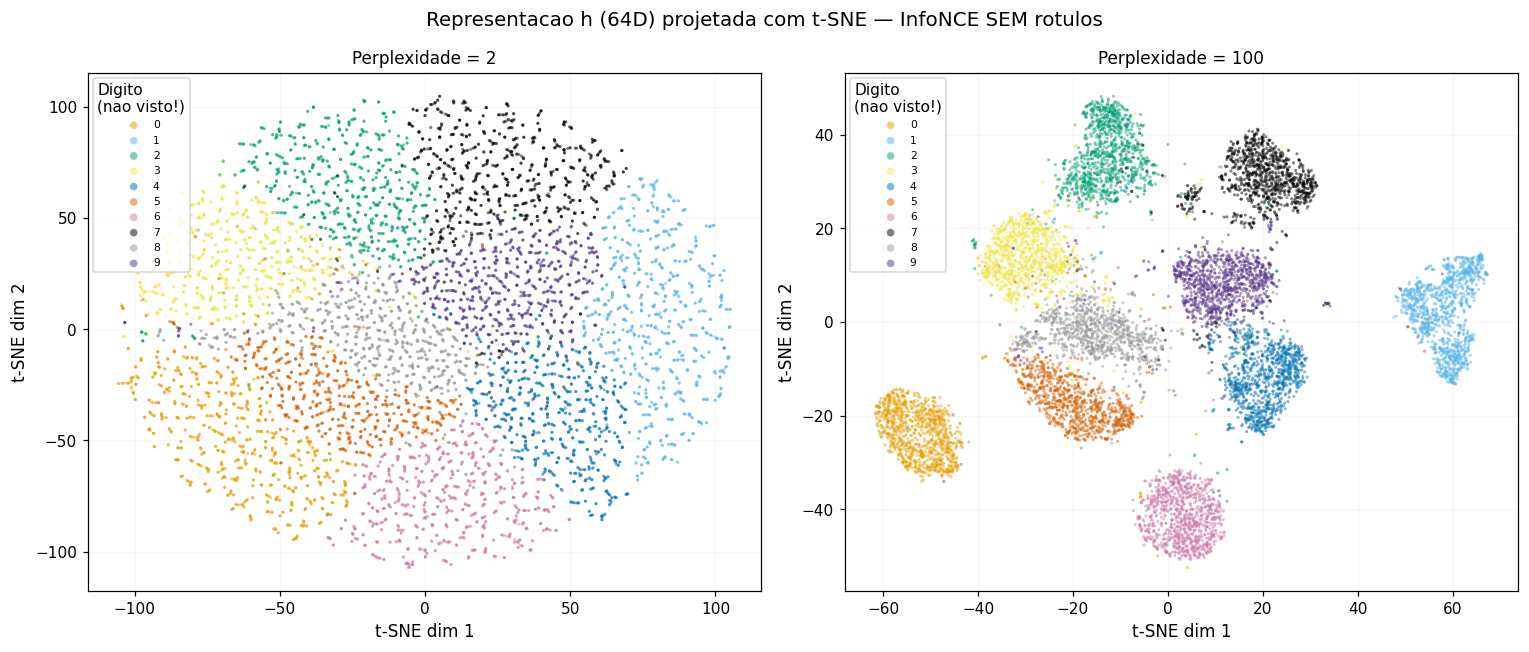

O encoder NUNCA viu rotulos — mas a representacao h
mostra agrupamentos claros por classe no t-SNE!

NOTA: distancias ENTRE clusters nao sao significativas (L3B1 §6.3).
O t-SNE preserva vizinhancas locais, nao geometria global.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Representacao h (64D) projetada com t-SNE — InfoNCE SEM rotulos", fontsize=13)

for c in range(10):
    mask = y_eval == c
    ax1.scatter(H_tsne_1[mask, 0], H_tsne_1[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))
    ax2.scatter(H_tsne_2[mask, 0], H_tsne_2[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))

ax1.set_title("Perplexidade = 2", fontsize=11)
ax2.set_title("Perplexidade = 100", fontsize=11)
for ax in (ax1, ax2):
    ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
    ax.legend(title="Digito\n(nao visto!)", fontsize=7, markerscale=2.5, framealpha=0.8)
    ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

In [ ]:
# Sonda linear: medida QUANTITATIVA da qualidade da representacao h
from sklearn.linear_model import LogisticRegression

# Representacoes de treino (para ajustar a sonda)
H_train = obter_representacao_h(modelo_ssl, X_train_cnn)

# Regressao logistica sobre h CONGELADO (nao treina o encoder)
sonda = LogisticRegression(max_iter=2000, random_state=42)
sonda.fit(H_train, y_train)
acc_ssl = sonda.score(H_eval, y_eval)

# Para comparacao: acuracia do classificador supervisionado da Parte 2
preds_sup = []
for i in range(0, len(X_eval_cnn), 512):
    logits_batch = jax.vmap(classificador)(X_eval_cnn[i:i + 512])
    preds_sup.append(np.array(jnp.argmax(logits_batch, axis=-1)))
preds_sup = np.concatenate(preds_sup)
acc_sup = float(np.mean(preds_sup == y_eval))

print("=== Avaliacao da representacao ===")
print(f"  Supervisionado (Parte 2, bottleneck 2D):  acuracia = {acc_sup:.1%}")
print(f"  InfoNCE + sonda linear (h, 64D):          acuracia = {acc_ssl:.1%}")

=== Avaliacao da representacao ===
  Supervisionado (Parte 2, bottleneck 2D):  acuracia = 88.5%
  InfoNCE + sonda linear (h, 64D):          acuracia = 94.7%
  Acaso (10 classes):                        acuracia = 10.0%

A sonda linear sobre h congelado atinge 94.7%!
O encoder aprendeu estrutura rica SEM nenhum rotulo de classe.


### Comparacao visual: supervisionado 2D vs InfoNCE t-SNE

A Parte 2 usou rotulos para forcar a estrutura em 2D.
A Parte 4 descobriu estrutura **sem rotulos**, numa representacao que projetamos com t-SNE para visualizar.

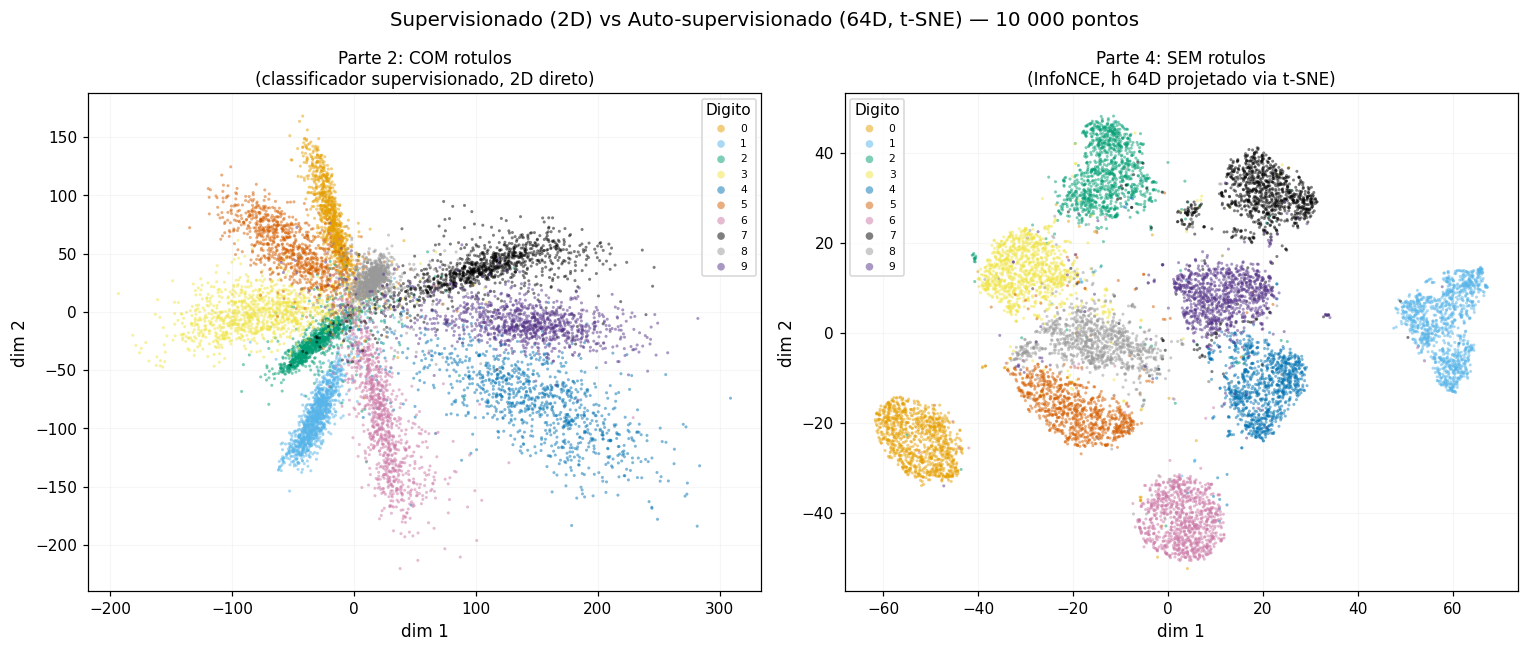

Ambos revelam estrutura de clusters — mas foram obtidos de formas muito diferentes:
  - Esquerda: rotulos disseram quem e quem (supervisionado)
  - Direita: so augmentacoes declararam 'estas vistas sao do mesmo objeto'


In [ ]:
# Lado a lado: supervisionado 2D vs InfoNCE t-SNE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Supervisionado (2D) vs Auto-supervisionado (64D, t-SNE) — 10 000 pontos", fontsize=13)

for c in range(10):
    mask = y_eval == c
    ax1.scatter(Z_sup[mask, 0], Z_sup[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))
    ax2.scatter(H_tsne_2[mask, 0], H_tsne_2[mask, 1], s=4, color=CORES[c], alpha=0.5, edgecolors="none", label=str(c))

ax1.set_title("Parte 2: COM rotulos\n(classificador supervisionado, 2D direto)", fontsize=11)
ax2.set_title("Parte 4: SEM rotulos\n(InfoNCE, h 64D projetado via t-SNE)", fontsize=11)
for ax in (ax1, ax2):
    ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
    ax.legend(title="Digito", fontsize=7, markerscale=2.5, framealpha=0.8)
    ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

**Nota honesta**:

- **O modelo nunca viu rotulos.** A unica informacao que guiou o
  treino foram as augmentacoes — "estas duas vistas sao do mesmo
  objeto." Que estrutura emerja dessas declaracoes e notavel.

- **A temperatura $\tau$** controla a nitidez dos contrastes
  (L3B1 §4.4): $\tau$ baixo foca nos negativos mais dificeis;
  $\tau$ alto suaviza. Experimente mudar `TAU` e re-treinar!

- **Batch grande importa** (L3B1 §4.5): mais negativos = tarefa
  mais dificil = representacoes mais finas. SimCLR e MoCo foram
  desenhados exatamente para maximizar o numero de negativos.